In [8]:
%load_ext autoreload
%autoreload 2

import torch
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

import numpy as np
import scipy
from scipy.interpolate import RegularGridInterpolator

import yaml
from tqdm import tqdm 

import os

import matplotlib.pyplot as plt
from neurorient.model import NeurOrient, NeurOrientLightning
from neurorient.utils_visualization import save_mrc, display_volumes, display_fsc, display_images
from neurorient.reconstruction.phasing import PhaseRetriever
from neurorient.metrics import compute_fsc
from neurorient.reconstruction.slicing import real_mesh_2_reciprocal_mesh
from neurorient.configurator    import Configurator

from sklearn.model_selection import train_test_split

import skopi as sk
import h5py
from pytorch3d.transforms import (
    matrix_to_quaternion, quaternion_to_matrix, so3_rotation_angle, so3_relative_angle,
    matrix_to_axis_angle
    )

device = 'cuda' if torch.cuda.is_available() else 'cpu'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from neurorient.utils_config import prepare_dataset, flags_long2short

In [10]:
pdb = '1BXR'
num_images = 10000
increase_factor = 1

In [11]:
size_detector = 250

In [12]:
with open(f'yaml/dragonfly_comparison_Newton_R1/{pdb.lower()}_resnet18_{increase_factor}x_coslr_fpb.yaml', 'r') as fh:
    config_dict = yaml.safe_load(fh)
CONFIG = Configurator.from_dict(config_dict)

In [13]:
spi_data = torch.load(f'/pscratch/sd/z/zhantao/neurorient_repo/data/dragonfly_data_Newton_R1/{pdb}_increase1_poissonFalse_size{size_detector}_num{num_images//1000:d}K.pt')
model_dir = '/pscratch/sd/z/zhantao/neurorient_repo/model_archived'
save_dir = '/pscratch/sd/z/zhantao/neurorient_repo/dragonfly_benchmark_data_Newton_R1'
print(spi_data.keys())

dict_keys(['orientations', 'intensities', 'pixel_position_reciprocal', 'pixel_index_map', 'volume', 'img_real_mesh', 'vol_real_mesh', 'time_stamp'])


In [14]:
dataset = prepare_dataset(CONFIG, spi_data['intensities'])

transformation: photon fluctuation applied to training and validation datasets.
transformation: poisson noise applied to training and validation datasets.
transformation: beam stop mask applied to training and validation datasets.
3 transformations applied to training and validation datasets.


100%|██████████| 10000/10000 [00:59<00:00, 166.89it/s]


created dataset with 10000 images.


In [15]:
slices_to_save = []
for i in range(len(dataset)):
    slices_to_save.append(dataset[i]['image'] * dataset[i]['general_mask'])
slices_to_save = torch.stack(slices_to_save).squeeze(1).numpy()

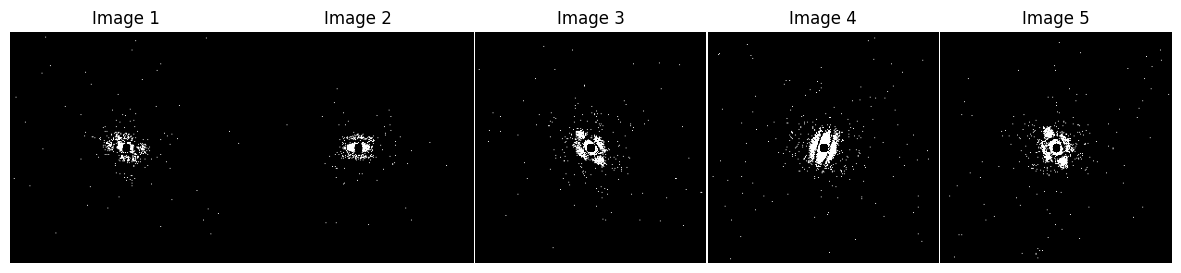

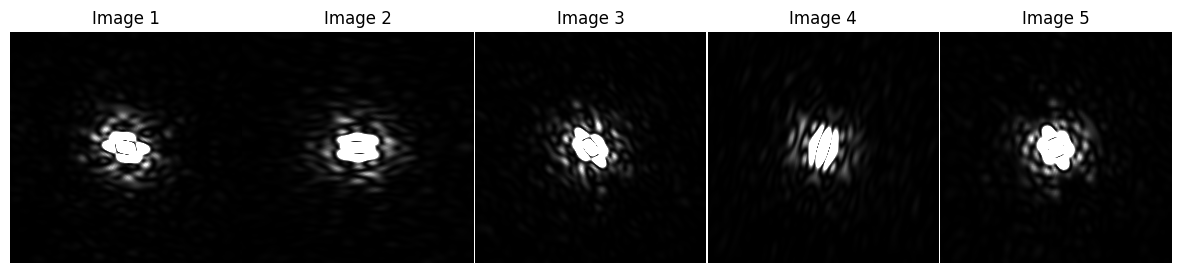

In [16]:
display_images(slices_to_save[:5], columns=5, vmax=1)
display_images(spi_data['intensities'][:5], columns=5, vmax=.1)

In [17]:
# display_images(slices_to_save[:5], columns=5, vmax=1)
# display_images(spi_data['intensities'][:5], columns=5, vmax=.1)

In [18]:
place_ones = []
place_multi = []
count_multi = []
for i, img in enumerate(slices_to_save):
    
    place_ones.append(np.where(img.reshape(-1) == 1)[0].astype('int32'))
    place_multi.append(np.where(img.reshape(-1) > 1)[0].astype('int32'))
    count_multi.append(img.reshape(-1)[place_multi[-1]].astype('int32'))
    # if i == 0:
    #     break

num_pix = np.array([len(img.reshape(-1))]).astype('int32')

place_ones = np.array(place_ones)
place_multi = np.array(place_multi)
count_multi = np.array(count_multi)

/tmp/ipykernel_265193/2590173341.py:14: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  place_ones = np.array(place_ones)
/tmp/ipykernel_265193/2590173341.py:15: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  place_multi = np.array(place_multi)
/tmp/ipykernel_265193/2590173341.py:16: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  count_

In [19]:
intensities_re = np.zeros((len(place_ones), num_pix[0]))

for i in tqdm(range(len(place_ones))):
    intensities_re[i, place_ones[i]] = 1
    intensities_re[i, place_multi[i]] = count_multi[i]
    if i == 5:
        break

  0%|          | 5/10000 [00:00<00:02, 4661.37it/s]


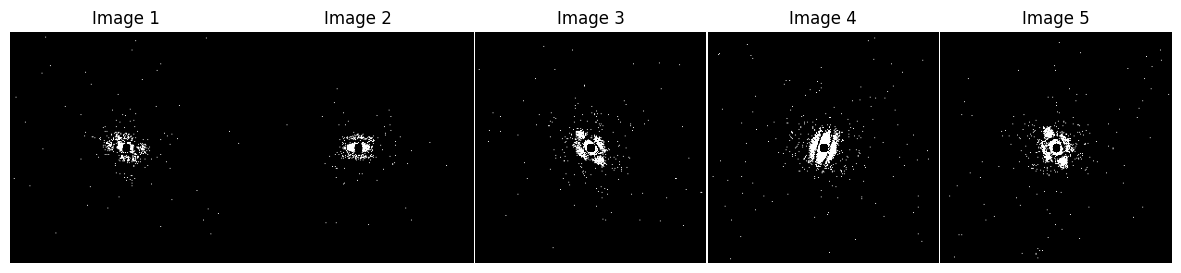

In [20]:
display_images(slices_to_save[:5].reshape(-1,size_detector,size_detector), columns=5, vmax=1)

In [21]:
h5_fpath = os.path.join(
    save_dir,
    f'{pdb}_increase{increase_factor:d}_num{num_images//1000}K_size{size_detector}_fpb.h5')
print(h5_fpath)

/pscratch/sd/z/zhantao/neurorient_repo/dragonfly_benchmark_data_Newton_R1/1BXR_increase1_num10K_size250_fpb.h5


In [22]:
with h5py.File(h5_fpath, 'w') as f:
    # f.create_dataset('place_ones', data=place_ones, dtype=np.dtype('O'))
    # f.create_dataset('place_multi', data=place_multi, dtype=np.dtype('O'))
    # f.create_dataset('count_multi', data=count_multi, dtype=np.dtype('O'))
    # f.create_dataset('num_pix', data=num_pix)
    # Variable-length datasets
    dt = h5py.vlen_dtype(np.dtype('int32'))
    f.create_dataset('place_ones', (len(place_ones),), dtype=dt, data=place_ones)
    f.create_dataset('place_multi', (len(place_ones),), dtype=dt, data=place_multi)
    f.create_dataset('count_multi', (len(place_ones),), dtype=dt, data=count_multi)
    f.create_dataset('num_pix', data=num_pix)
print('data wrote to: \n', h5_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/dragonfly_benchmark_data_Newton_R1/1BXR_increase1_num10K_size250_fpb.h5


In [23]:
# Open the .h5 file
with h5py.File(h5_fpath, 'r') as file:
    # Print the loaded data
    print(file.keys())
    
    re_place_ones = file['place_ones'][:]
    re_num_pix = file['num_pix'][:]
    re_place_multi = file['place_multi'][:]
    re_count_multi = file['count_multi'][:]

<KeysViewHDF5 ['count_multi', 'num_pix', 'place_multi', 'place_ones']>
